In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setting visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.weight'] = 'bold'

In [2]:

train_df = pd.read_csv('train.csv')

target = 'Loan Sanction Amount (USD)'
X = train_df.drop(['Customer ID', 'Name', target], axis=1)
y = train_df[target].fillna(train_df[target].median())

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": GridSearchCV(Ridge(), {'alpha': [0.1, 1, 10, 100]}, cv=5),
    "Lasso Regression": GridSearchCV(Lasso(max_iter=5000), {'alpha': [0.1, 1, 10]}, cv=5),
    "Elastic Net": GridSearchCV(ElasticNet(), {'alpha': [0.1, 1], 'l1_ratio': [0.5]}, cv=5)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    start = time.time()
    pipe = Pipeline([('pre', preprocessor), ('reg', model)])
    pipe.fit(X_train, y_train)
    train_time = time.time() - start
    trained_pipelines[name] = pipe

    for set_name, x_set, y_set in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        pred = pipe.predict(x_set)
        results.append({
            "Model": name, "Set": set_name,
            "MAE": mean_absolute_error(y_set, pred),
            "MSE": mean_squared_error(y_set, pred),
            "RMSE": np.sqrt(mean_squared_error(y_set, pred)),
            "R2": r2_score(y_set, pred),
            "Time(s)": train_time if set_name == "Train" else 0
        })

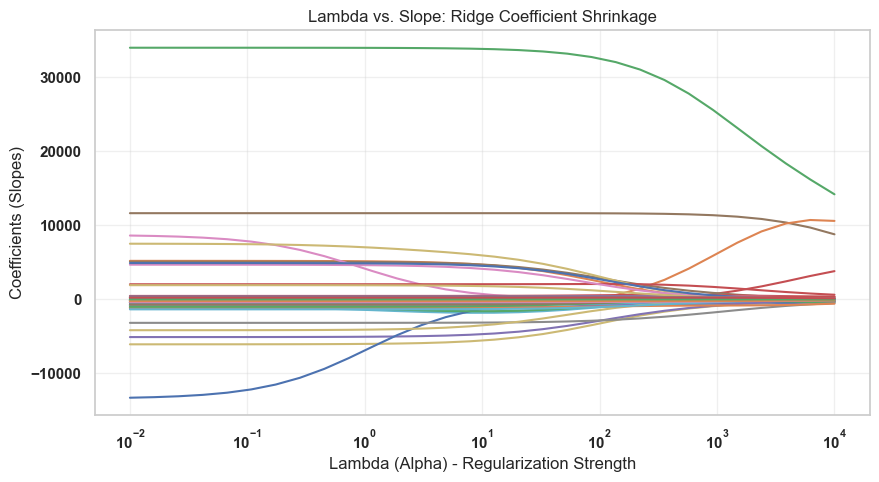

In [4]:
alphas = np.logspace(-2, 4, 30)
coefs = []
X_transformed = preprocessor.fit_transform(X_train)

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_transformed, y_train)
    coefs.append(ridge.coef_)

plt.figure(figsize=(10, 5))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Lambda (Alpha) - Regularization Strength')
plt.ylabel('Coefficients (Slopes)')
plt.title('Lambda vs. Slope: Ridge Coefficient Shrinkage')
plt.grid(True, alpha=0.3)
plt.show()

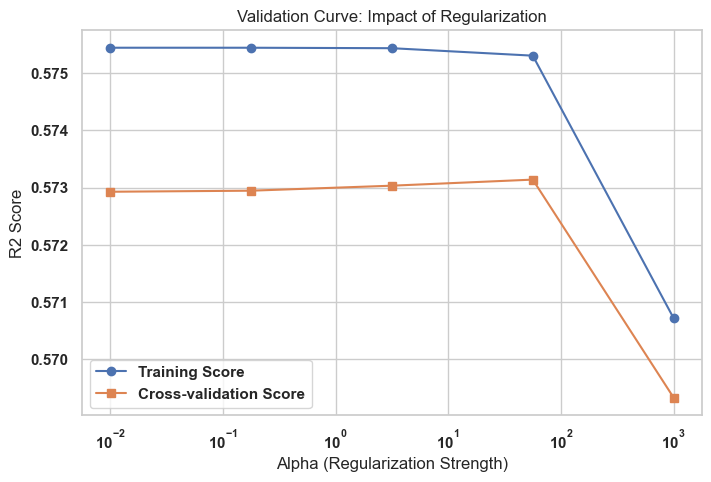

In [5]:
param_range = np.logspace(-2, 3, 5)
train_scores, test_scores = validation_curve(
    Ridge(), X_transformed, y_train,
    param_name="alpha", param_range=param_range, cv=5, scoring="r2"
)

plt.figure(figsize=(8, 5))
plt.plot(param_range, np.mean(train_scores, axis=1), 'o-', label="Training Score")
plt.plot(param_range, np.mean(test_scores, axis=1), 's-', label="Cross-validation Score")
plt.xscale('log')
plt.title("Validation Curve: Impact of Regularization")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("R2 Score")
plt.legend()
plt.show()

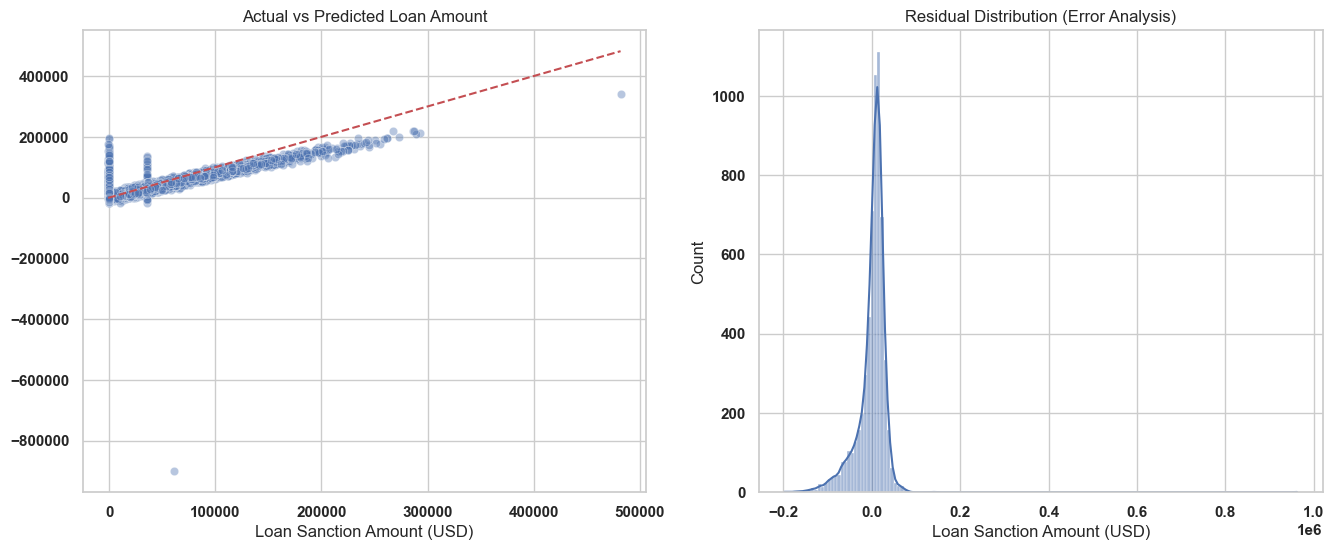

In [6]:
best_model = trained_pipelines["Ridge Regression"]
y_pred_test = best_model.predict(X_test)
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred_test, ax=axes[0], alpha=0.4)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Actual vs Predicted Loan Amount")

# Residuals
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution (Error Analysis)")
plt.show()

In [9]:
res_df = pd.DataFrame(results)

print("--- TABLE 2: TRAIN SET PERFORMANCE ---")
display(res_df[res_df['Set'] == 'Train'].round(4))

print("\n--- TABLE 3: TEST SET PERFORMANCE ---")
display(res_df[res_df['Set'] == 'Test'].round(4))

feat_names = numeric_features.tolist()
table_4_data = {
    "Linear": trained_pipelines["Linear Regression"]['reg'].coef_[:5],
    "Ridge": trained_pipelines["Ridge Regression"]['reg'].best_estimator_.coef_[:5],
    "Lasso": trained_pipelines["Lasso Regression"]['reg'].best_estimator_.coef_[:5],
    "Elastic Net": trained_pipelines["Elastic Net"]['reg'].best_estimator_.coef_[:5] # Added this
}
print("\n--- TABLE 4: COEFFICIENT COMPARISON (Top 5 Features) ---")
display(pd.DataFrame(table_4_data, index=feat_names[:5]).round(4))

--- TABLE 2: TRAIN SET PERFORMANCE ---


,Model,Set,MAE,MSE,RMSE,R2,Time(s)
0,Linear Regression,Train,21820.7534,9.773486e+08,31262.5745,0.5752,0.0867
2,Ridge Regression,Train,21840.4346,9.778067e+08,31269.9016,0.5750,0.3153
4,Lasso Regression,Train,21821.3653,9.776211e+08,31266.9326,0.5751,175.1844
6,Elastic Net,Train,22057.3488,9.876088e+08,31426.2439,0.5707,8.0800



--- TABLE 3: TEST SET PERFORMANCE ---


,Model,Set,MAE,MSE,RMSE,R2,Time(s)
1,Linear Regression,Test,21844.6051,1.113582e+09,33370.3816,0.5160,0.0
3,Ridge Regression,Test,21844.3746,1.105101e+09,33243.0643,0.5196,0.0
5,Lasso Regression,Test,21825.4303,1.105845e+09,33254.2531,0.5193,0.0
7,Elastic Net,Test,21990.5791,1.052871e+09,32447.9750,0.5423,0.0



--- TABLE 4: COEFFICIENT COMPARISON (Top 5 Features) ---


,Linear,Ridge,Lasso,Elastic Net
Age,-655.7011,-623.8695,-622.6106,-585.5492
Income (USD),5194.9144,2399.3347,2912.9928,114.2131
Loan Amount Request (USD),33956.4175,32502.1070,33741.1043,24240.0100
Current Loan Expenses (USD),-457.9435,-285.8125,-414.2888,946.6010
Dependents,-419.6046,-416.7425,-408.9932,-359.5769
